In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
data_path = "/content/drive/MyDrive/HocMayvaUngDung/Project/Data/computer_prices_all.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [4]:
print(df.dtypes)

device_type             object
brand                   object
model                   object
release_year             int64
os                      object
form_factor             object
cpu_brand               object
cpu_model               object
cpu_tier                 int64
cpu_cores                int64
cpu_threads              int64
cpu_base_ghz           float64
cpu_boost_ghz          float64
gpu_brand               object
gpu_model               object
gpu_tier                 int64
vram_gb                  int64
ram_gb                   int64
storage_type            object
storage_gb               int64
storage_drive_count      int64
display_type            object
display_size_in        float64
resolution              object
refresh_hz               int64
battery_wh               int64
charger_watts            int64
psu_watts                int64
wifi                    object
bluetooth              float64
weight_kg              float64
warranty_months          int64
price   

In [5]:
missing_values = df.isnull().sum()
missing_values

,0
device_type,0
brand,0
model,0
release_year,0
os,0
form_factor,0
cpu_brand,0
cpu_model,0
cpu_tier,0
cpu_cores,0


In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [7]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()

print(f"Number of categorical features: {len(categorical_cols)}")
print(categorical_cols)

Number of categorical features: 13
['device_type', 'brand', 'model', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'resolution', 'wifi']


In [8]:
label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    df_encoded[col] = encoder.fit_transform(df_encoded[col].astype(str))

    label_encoders[col] = encoder

df_encoded.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,0,9,94022,2022,2,1,2,17269,3,12,24,2.8,3.8,3,26,2,6,16,2,1024,1,1,27.0,1,90,0,0,750,1,5.1,11.00,36,1383.99
1,1,9,95455,2022,2,4,2,21727,4,12,24,2.6,3.6,3,28,4,10,64,2,512,1,3,16.0,0,90,56,120,0,1,5.3,2.03,12,2274.99
2,0,6,76938,2024,3,7,0,4826,2,8,16,2.6,3.6,3,25,1,4,8,2,512,2,1,32.0,4,120,0,0,850,1,5.0,7.00,24,1879.99
3,0,3,35785,2024,2,1,0,6970,2,6,12,2.6,3.6,0,44,2,6,16,0,512,2,0,27.0,4,120,0,0,650,1,5.2,6.00,36,1331.99
4,1,4,48178,2024,1,3,0,10023,5,16,32,2.8,3.9,3,23,5,12,96,2,256,1,2,15.6,2,90,80,90,0,1,5.2,1.50,12,2681.99


In [9]:
#Chọn các biến liên tục
continuous_features = [
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "display_size_in",
    "weight_kg",
    "battery_wh",
    "storage_gb",
    "charger_watts",
    "psu_watts",
    "bluetooth",
    "price"
]

print(f"Number of continuous features: {len(continuous_features)}")
continuous_features

Number of continuous features: 10


['cpu_base_ghz',
 'cpu_boost_ghz',
 'display_size_in',
 'weight_kg',
 'battery_wh',
 'storage_gb',
 'charger_watts',
 'psu_watts',
 'bluetooth',
 'price']

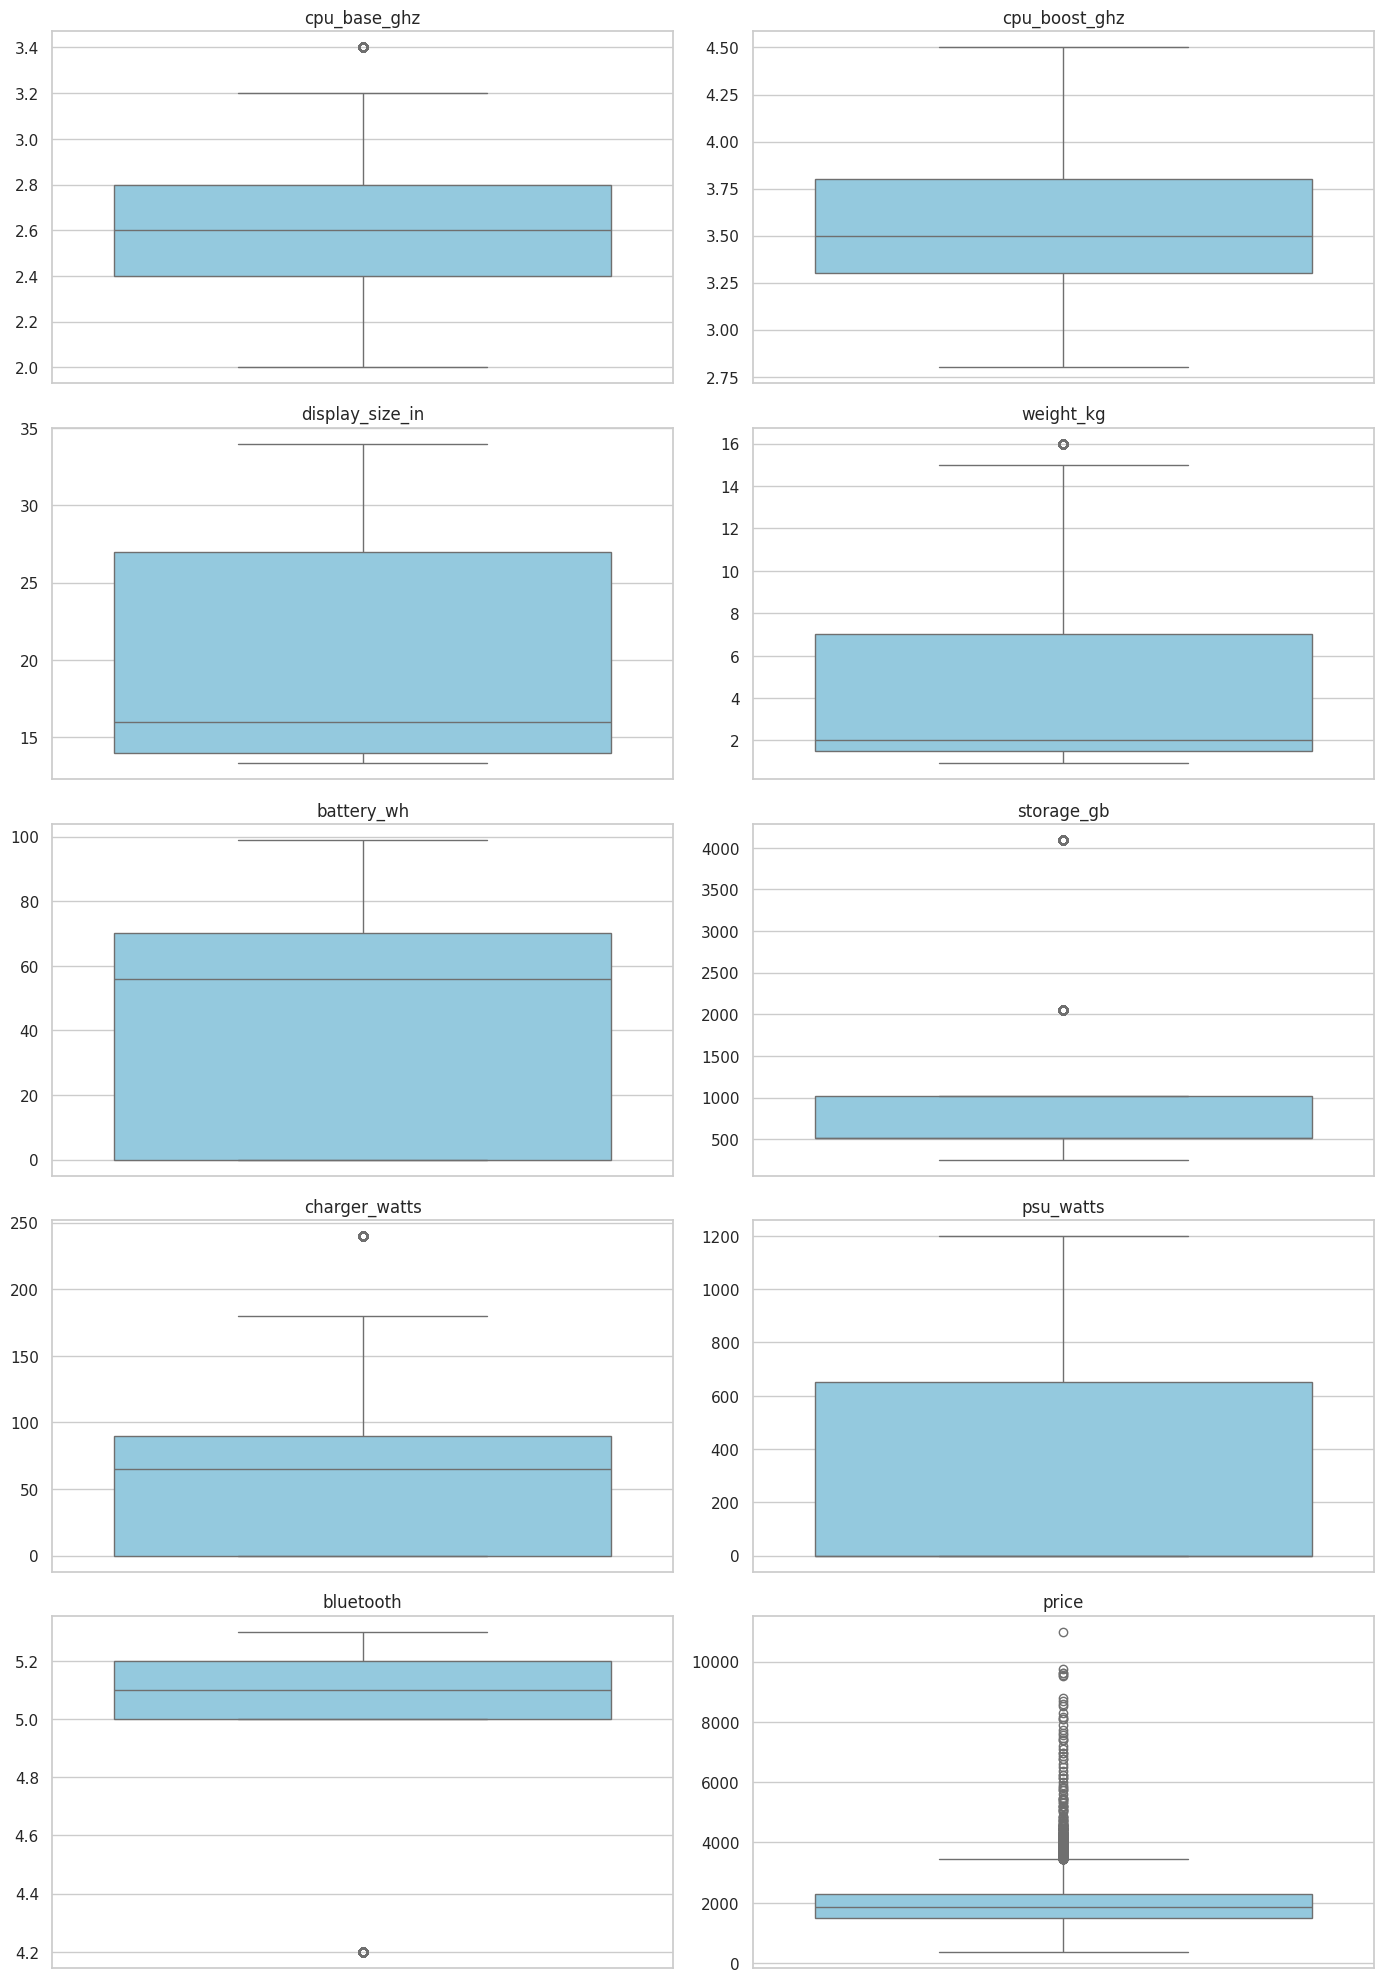

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

plt.figure(figsize=(14, n_rows * 4))

for i, col in enumerate(continuous_features):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        y=df_encoded[col],
        color="skyblue"
    )

    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [11]:
outlier_summary = []

for col in continuous_features:

    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_encoded[
        (df_encoded[col] < lower) |
        (df_encoded[col] > upper)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage (%)": round(len(outliers) / len(df_encoded) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Outliers,Percentage (%)
0,cpu_base_ghz,1978,1.98
1,cpu_boost_ghz,0,0.00
2,display_size_in,0,0.00
3,weight_kg,1031,1.03
4,battery_wh,0,0.00
5,storage_gb,14811,14.81
6,charger_watts,3039,3.04
7,psu_watts,0,0.00
8,bluetooth,5939,5.94
9,price,976,0.98


In [12]:
df_processed = df_encoded.copy()

for col in continuous_features:

    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_processed[col] = df_processed[col].clip(lower, upper)

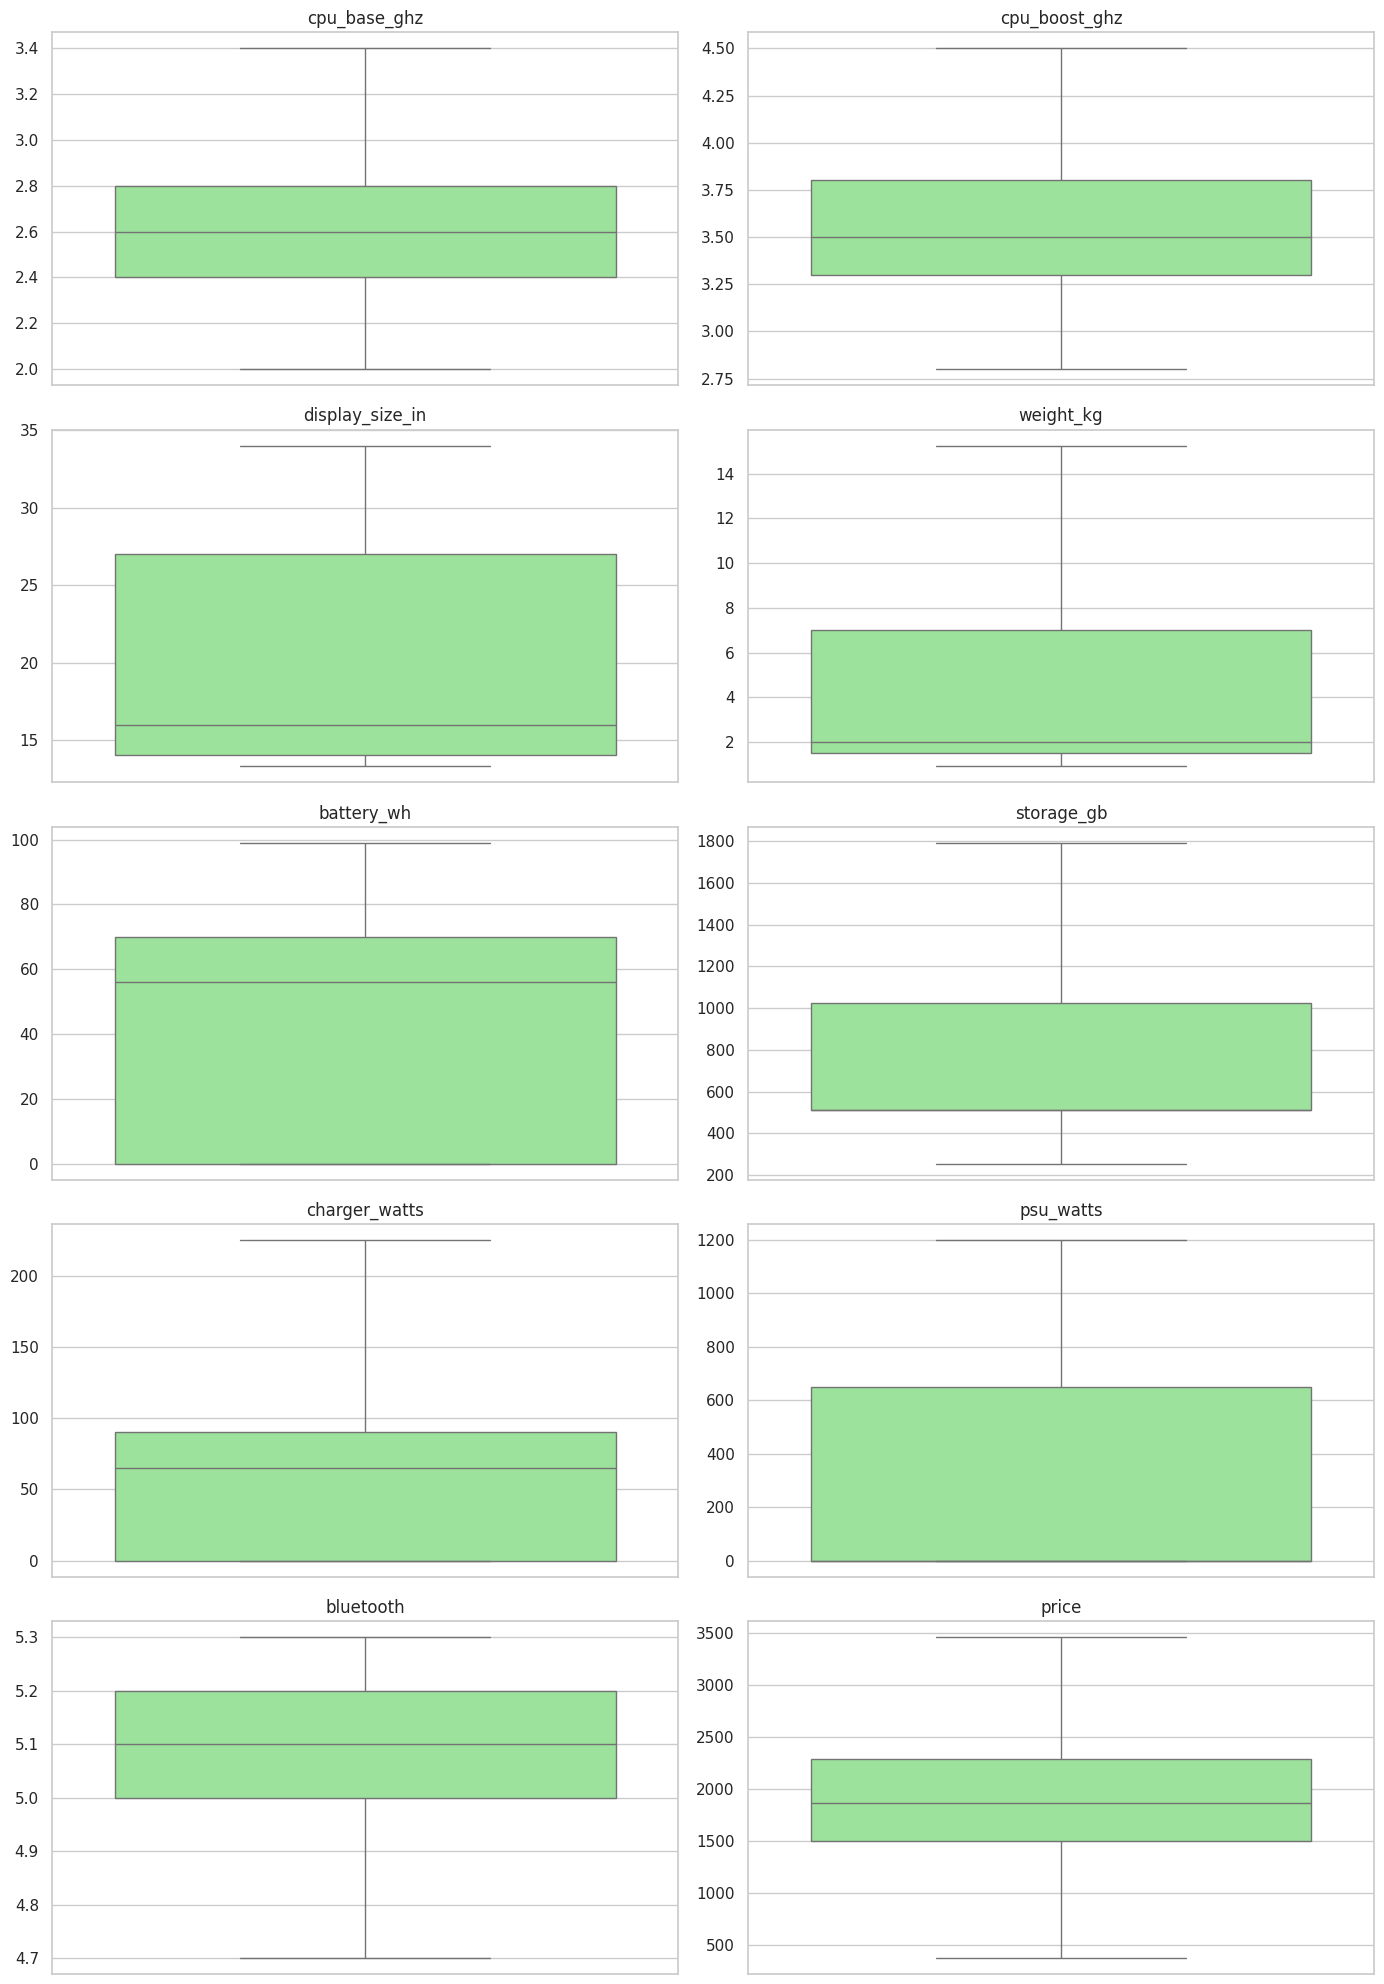

In [13]:
n_cols = 2
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

plt.figure(figsize=(14, n_rows * 4))

for i, col in enumerate(continuous_features):

    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        y=df_processed[col],
        color="lightgreen"
    )

    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

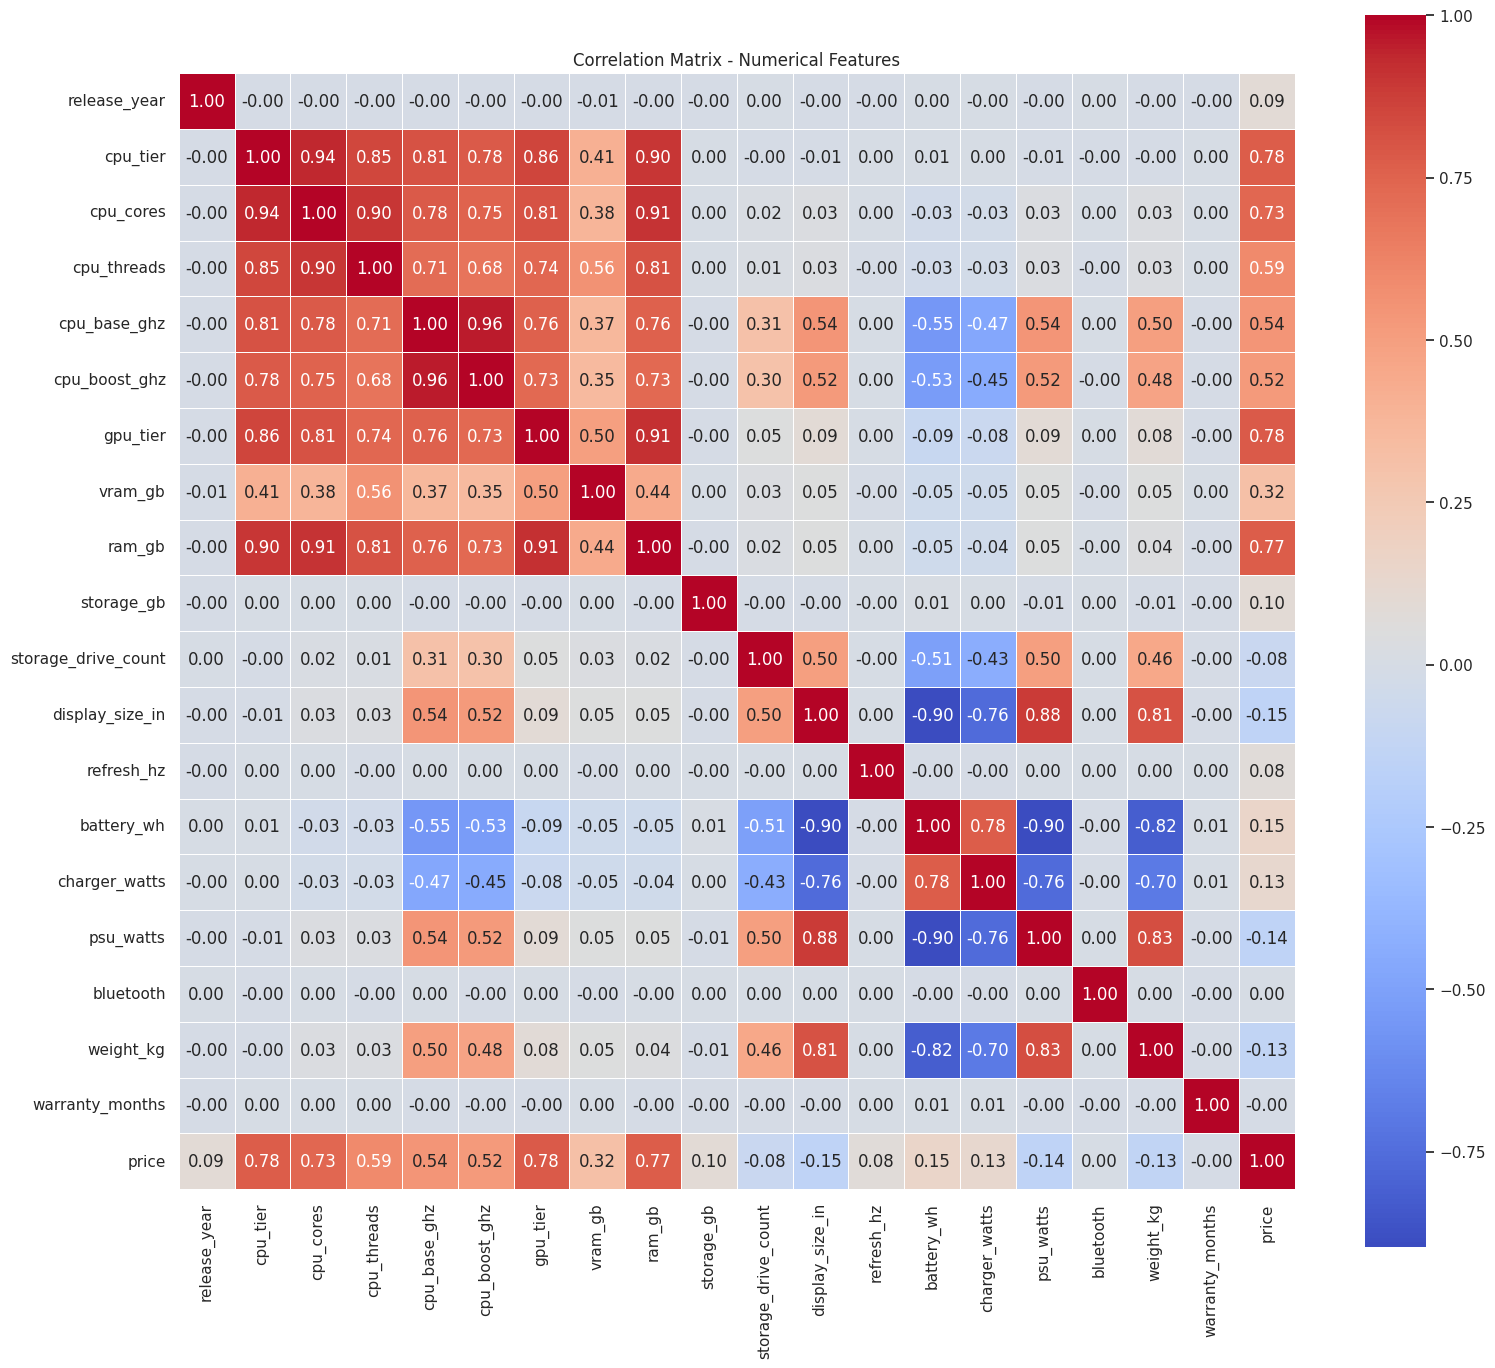

In [14]:
numerical_features = ["release_year","cpu_tier","cpu_cores","cpu_threads","cpu_base_ghz",
                      "cpu_boost_ghz","gpu_tier","vram_gb","ram_gb","storage_gb","storage_drive_count",
                      "display_size_in","refresh_hz","battery_wh","charger_watts","psu_watts",
                      "bluetooth","weight_kg","warranty_months"]

corr_numeric = df_processed[
    numerical_features + ["price"]
].corr()

plt.figure(figsize=(18,16))

sns.heatmap(
    corr_numeric,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    linecolor="white",
    square=True
)

plt.title("Correlation Matrix - Numerical Features")

plt.show()

In [15]:
corr_num = corr_numeric["price"].drop("price")

feature_rank_num = pd.DataFrame({
    "Feature": corr_num.index,
    "Correlation": corr_num.values,
    "AbsCorrelation": corr_num.abs().values
})

feature_rank_num = feature_rank_num.sort_values(
    by="AbsCorrelation",
    ascending=False
)

feature_rank_num

threshold = 0.50

chosen_numeric = feature_rank_num[
    feature_rank_num["AbsCorrelation"] >= threshold
]["Feature"].tolist()

print(chosen_numeric)

['gpu_tier', 'cpu_tier', 'ram_gb', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz']


In [16]:
corr_cat = df_processed[
    categorical_cols + ["price"]
].corr()

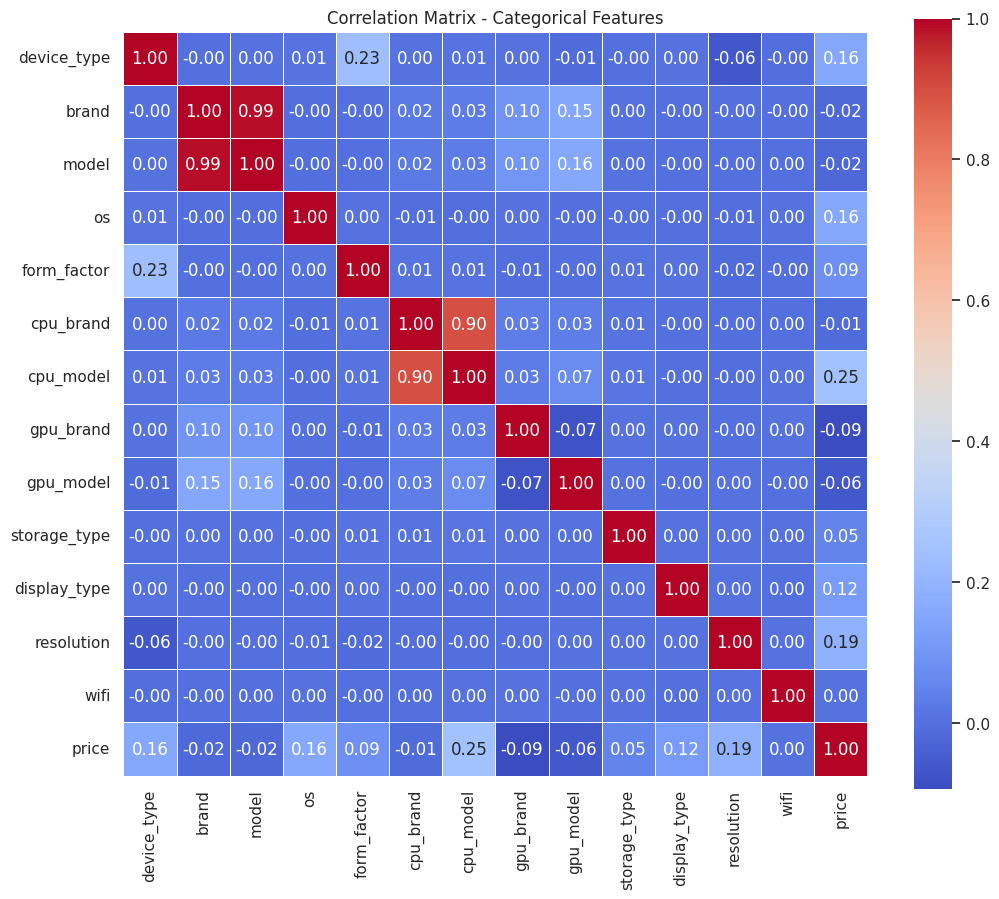

In [17]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_cat,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    linecolor="white",
    square=True
)

plt.title("Correlation Matrix - Categorical Features")

plt.show()

In [18]:
corr_price_cat = corr_cat["price"].drop("price")

feature_rank_cat = pd.DataFrame({
    "Feature": corr_price_cat.index,
    "Correlation": corr_price_cat.values,
    "AbsCorrelation": corr_price_cat.abs().values
})

feature_rank_cat = feature_rank_cat.sort_values(
    by="AbsCorrelation",
    ascending=False
)

feature_rank_cat

threshold = 0.1

chosen_categorical = feature_rank_cat[
    feature_rank_cat["AbsCorrelation"] >= threshold
]["Feature"].tolist()

print(chosen_categorical)

['cpu_model', 'resolution', 'os', 'device_type', 'display_type']


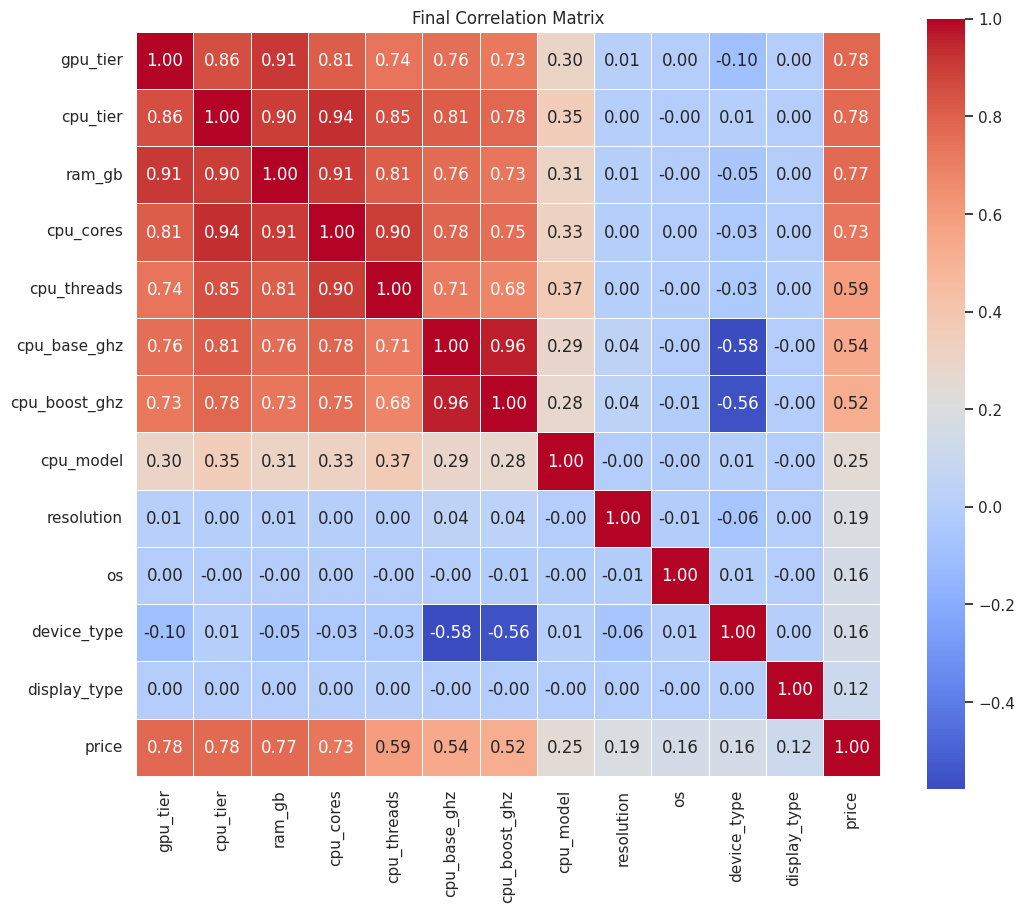

In [19]:
#Tổng hợp 2 Ma trận tương quan
chosen_features = (
    chosen_numeric + chosen_categorical
)

corr_final = df_processed[
    chosen_features + ["price"]
].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_final,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    linecolor="white",
    square=True
)

plt.title("Final Correlation Matrix")

plt.show()

In [20]:
#Loại bỏ đặc trưng có ảnh hưởng như nhau
corr = corr_final.drop(index="price", columns="price").abs()

upper = corr.where(
    np.triu(np.ones(corr.shape),k=1).astype(bool)
)

to_drop = []

for col in upper.columns:

    high_corr = upper[col][upper[col] > 0.90]

    if len(high_corr):

        for row in high_corr.index:

            corr_col = abs(corr_final.loc[col,"price"])
            corr_row = abs(corr_final.loc[row,"price"])

            if corr_col >= corr_row:
                to_drop.append(row)
            else:
                to_drop.append(col)

to_drop = list(set(to_drop))

print(to_drop)

final_features = [
    f for f in chosen_features
    if f not in to_drop
]

print("Chosen Features:")
print(final_features)

['ram_gb', 'cpu_boost_ghz', 'cpu_cores']
Chosen Features:
['gpu_tier', 'cpu_tier', 'cpu_threads', 'cpu_base_ghz', 'cpu_model', 'resolution', 'os', 'device_type', 'display_type']


In [21]:
#Chia tập và chuẩn hóa dữ liệu
X = df_processed[chosen_features]
y = df_processed["price"]

In [22]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Chuyển về DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=chosen_features,
    index=X.index
)

X_scaled.head()

,gpu_tier,cpu_tier,ram_gb,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,cpu_model,resolution,os,device_type,display_type
0,-0.679177,-0.111778,-0.743089,0.294259,0.476139,0.620265,0.767636,0.433499,-0.230310,-0.069354,-1.220773,-0.626677
1,0.691029,0.616465,0.761495,0.294259,0.476139,0.025794,0.196244,1.076434,-0.810101,-0.069354,0.819153,0.723381
2,-1.364279,-0.840021,-0.993852,-0.498752,-0.347044,0.025794,0.196244,-1.361037,1.509062,1.519879,-1.220773,-0.626677
3,-0.679177,-0.840021,-0.743089,-0.895258,-0.758635,0.025794,0.196244,-1.051828,1.509062,-0.069354,-1.220773,-1.301706
4,1.376131,1.344708,1.764550,1.087269,1.299322,0.620265,1.053332,-0.611523,0.349480,-1.658588,0.819153,0.048352


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,y,
    test_size=0.2,random_state=42,shuffle=True
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 12)
(20000, 12)
(80000,)
(20000,)


In [ ]:
#Huấn luyện mô hình
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

In [ ]:
#LinearRegression
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [ ]:
#RandomForest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
#XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [ ]:
#Chức năng đánh giá mô hình
def evaluate_model(model_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
results = []

results.append(evaluate_model("Linear Regression",y_test,lr_pred))

results.append(evaluate_model("Random Forest",y_test,rf_pred))

results.append(evaluate_model("XGBoost",y_test,xgb_pred))

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,model,MAE,MSE,RMSE,R2
0,XGBoost,167.033868,46590.130473,215.847470,0.852878
1,Random Forest,184.469220,57020.814785,238.790316,0.819941
2,Linear Regression,197.172810,63386.293027,251.766346,0.799840


In [ ]:
predictions = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

In [ ]:
best_model_name = results_df.iloc[0]["model"]

best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


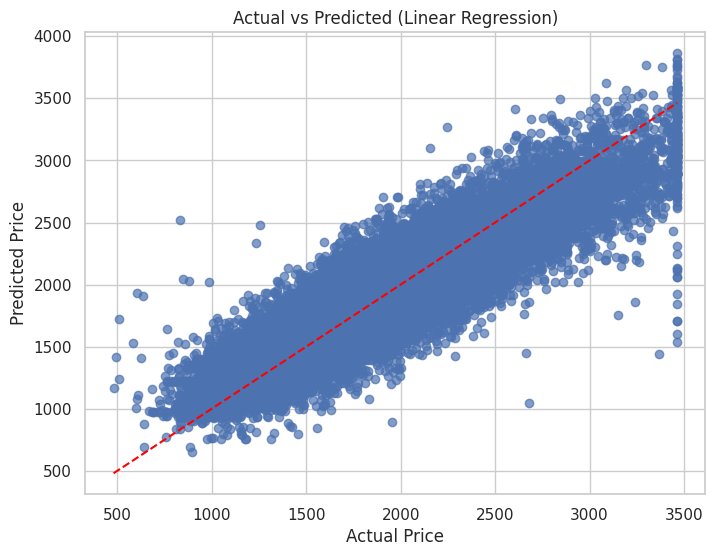

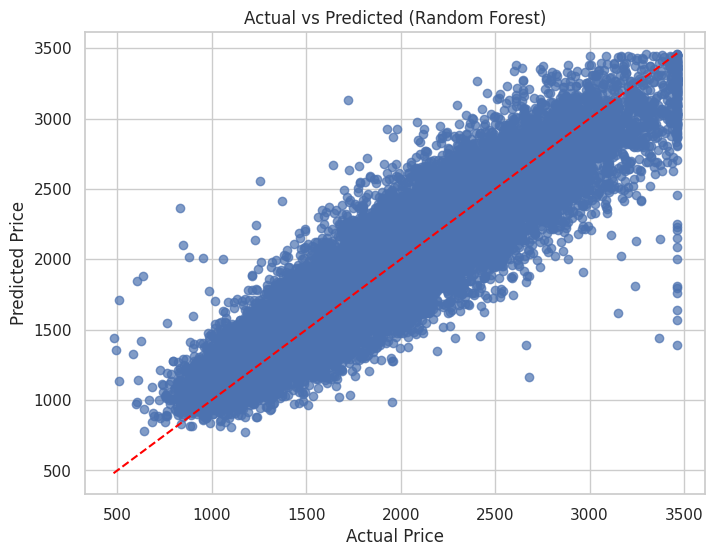

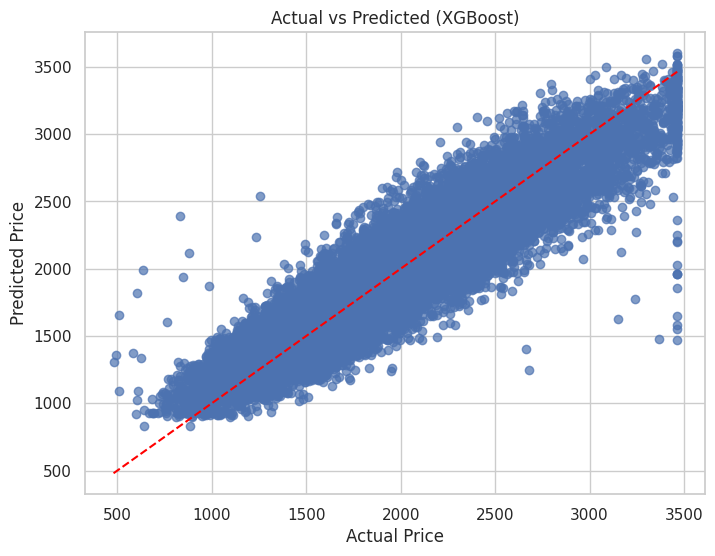

In [ ]:
#Trực quan hóa kết quả dự báo của 3 mô hình
predictions = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for model_name, pred in predictions.items():

    plt.figure(figsize=(8,6))

    plt.scatter(
        y_test,
        pred,
        alpha=0.7
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red",
        linestyle="--"
    )

    plt.xlabel("Actual Price")

    plt.ylabel("Predicted Price")

    plt.title(f"Actual vs Predicted ({model_name})")

    plt.grid(True)

    plt.show()

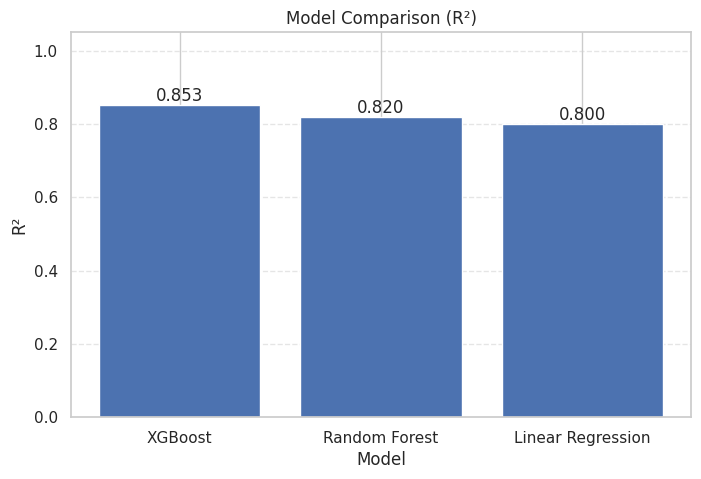

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results_df["model"], results_df["R2"])

plt.title("Model Comparison (R²)")
plt.xlabel("Model")
plt.ylabel("R²")

for i, v in enumerate(results_df["R2"]):
    plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()